# Data Process



데이터 처리를 위해 우선 데이터의 형태를 확인하자.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

train_data = pd.read_csv("./data/kdd99_train.csv")
test_data = pd.read_csv("./data/kdd99_test.csv")


데이터의 공격타입 종류를 확인하자.

In [2]:
train_data['Attack Type'].unique()

array(['normal', 'dos', 'probe', 'r2l', 'u2r'], dtype=object)

Attack type을 라벨링하기.

In [3]:
train_data["Attack Type"] = train_data["Attack Type"].replace({
    'dos' : 0,
    "probe" : 0,
    "r2l" : 0,
    "u2r" : 0,
    "normal" : 1
})
train_data

/var/folders/vf/d0gygbv5527dd2h9xypg_1zm0000gn/T/ipykernel_3008/1898562760.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  train_data["Attack Type"] = train_data["Attack Type"].replace({


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,Attack Type
0,0,tcp,http,SF,316,343,0,0,0,0,...,255,1.00,0.00,0.01,0.04,0.0,0.0,0.0,0.0,1
1,0,icmp,ecr_i,SF,1032,0,0,0,0,0,...,255,1.00,0.00,1.00,0.00,0.0,0.0,0.0,0.0,0
2,0,tcp,private,S0,0,0,0,0,0,0,...,10,0.04,0.07,0.00,0.00,1.0,1.0,0.0,0.0,0
3,0,tcp,private,S0,0,0,0,0,0,0,...,18,0.07,0.05,0.00,0.00,1.0,1.0,0.0,0.0,0
4,0,tcp,private,REJ,0,0,0,0,0,0,...,4,0.02,0.07,0.00,0.00,0.0,0.0,1.0,1.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395211,0,icmp,ecr_i,SF,1032,0,0,0,0,0,...,255,1.00,0.00,1.00,0.00,0.0,0.0,0.0,0.0,0
395212,0,tcp,private,S0,0,0,0,0,0,0,...,8,0.03,0.06,0.00,0.00,1.0,1.0,0.0,0.0,0
395213,0,icmp,ecr_i,SF,1032,0,0,0,0,0,...,255,1.00,0.00,1.00,0.00,0.0,0.0,0.0,0.0,0
395214,9141,udp,other,SF,147,105,0,0,0,0,...,3,0.01,0.41,0.84,0.00,0.0,0.0,0.0,0.0,1


공격과 정상 갯수 확인하자.

In [4]:
train_data["Attack Type"].value_counts()

Attack Type
0    317305
1     77911
Name: count, dtype: int64

In [5]:
numerical_cols = train_data._get_numeric_data().columns
categorical_cols = list(set(train_data.columns) - set(numerical_cols))

categorical_cols

['flag', 'protocol_type', 'service']

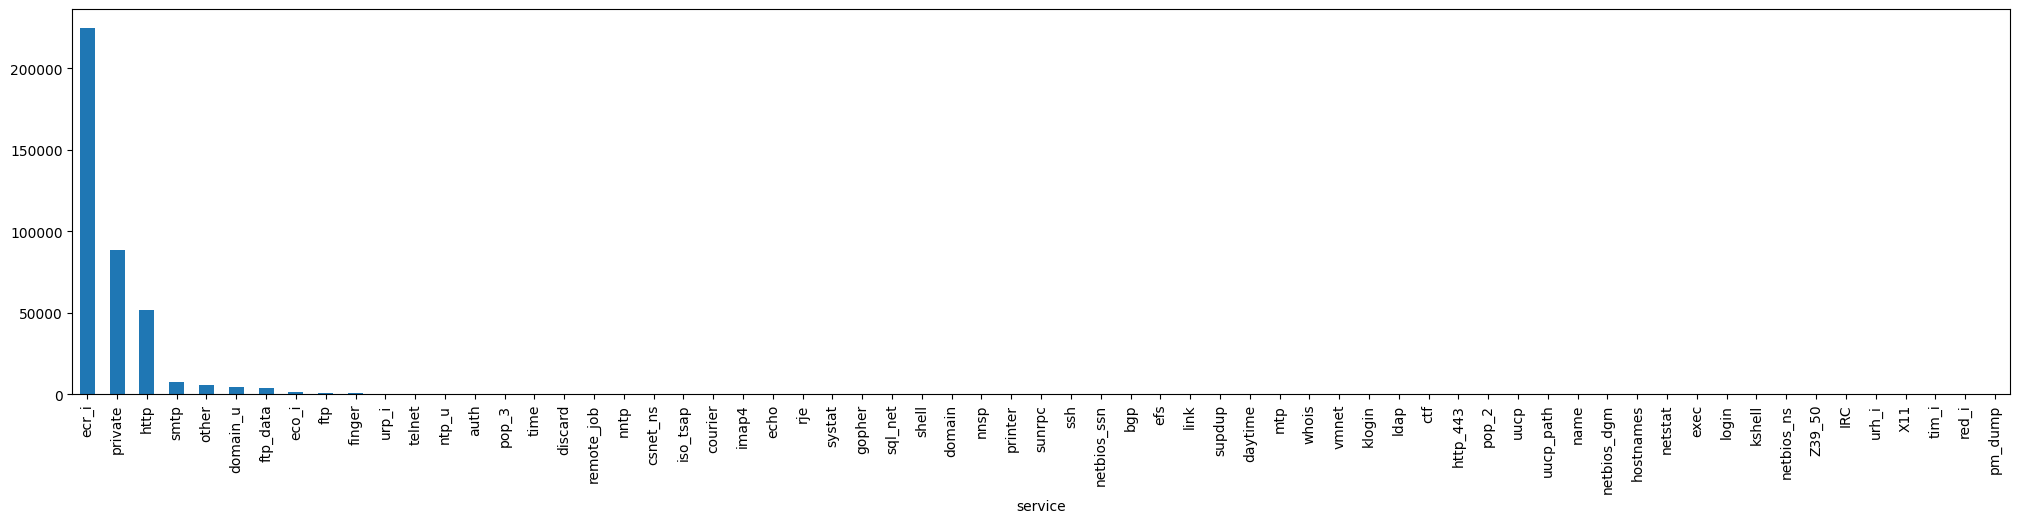

In [6]:
def value_count_bar(col):
    train_data[col].value_counts().plot(kind = "bar")

plt.figure(figsize = (25,5))
value_count_bar('service')

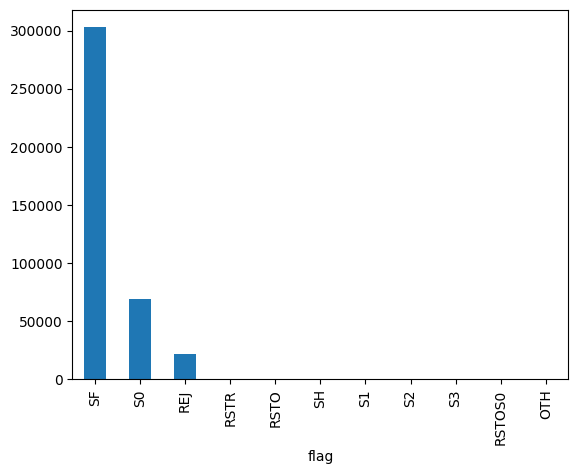

In [7]:
value_count_bar('flag')

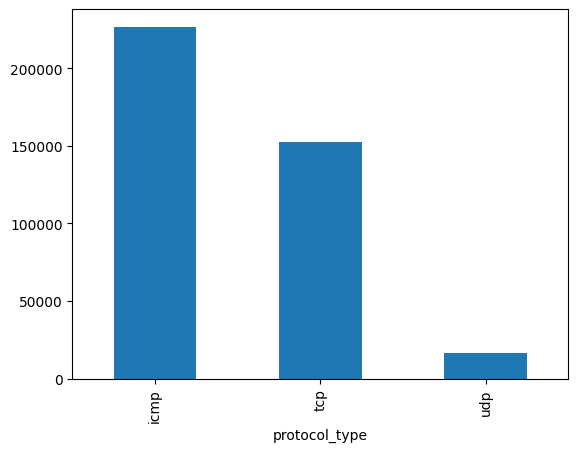

In [8]:
value_count_bar('protocol_type')

In [9]:
train_data = train_data.drop_duplicates()
train_data


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,Attack Type
0,0,tcp,http,SF,316,343,0,0,0,0,...,255,1.00,0.00,0.01,0.04,0.00,0.00,0.0,0.0,1
1,0,icmp,ecr_i,SF,1032,0,0,0,0,0,...,255,1.00,0.00,1.00,0.00,0.00,0.00,0.0,0.0,0
2,0,tcp,private,S0,0,0,0,0,0,0,...,10,0.04,0.07,0.00,0.00,1.00,1.00,0.0,0.0,0
3,0,tcp,private,S0,0,0,0,0,0,0,...,18,0.07,0.05,0.00,0.00,1.00,1.00,0.0,0.0,0
4,0,tcp,private,REJ,0,0,0,0,0,0,...,4,0.02,0.07,0.00,0.00,0.00,0.00,1.0,1.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395183,9,udp,private,SF,105,146,0,0,0,0,...,236,0.93,0.01,0.01,0.00,0.00,0.00,0.0,0.0,1
395197,0,tcp,finger,SF,8,137,0,0,0,0,...,14,0.04,0.13,0.02,0.14,0.00,0.00,0.0,0.0,1
395203,37,tcp,http,SF,211,189,0,0,0,0,...,255,1.00,0.00,0.00,0.00,0.00,0.00,0.0,0.0,1
395206,0,tcp,smtp,SF,1435,336,0,0,0,0,...,88,0.74,0.05,0.01,0.00,0.01,0.01,0.0,0.0,1


결측치를 제거해보자.

In [10]:
train_data = train_data.dropna()
train_data


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,Attack Type
0,0,tcp,http,SF,316,343,0,0,0,0,...,255,1.00,0.00,0.01,0.04,0.00,0.00,0.0,0.0,1
1,0,icmp,ecr_i,SF,1032,0,0,0,0,0,...,255,1.00,0.00,1.00,0.00,0.00,0.00,0.0,0.0,0
2,0,tcp,private,S0,0,0,0,0,0,0,...,10,0.04,0.07,0.00,0.00,1.00,1.00,0.0,0.0,0
3,0,tcp,private,S0,0,0,0,0,0,0,...,18,0.07,0.05,0.00,0.00,1.00,1.00,0.0,0.0,0
4,0,tcp,private,REJ,0,0,0,0,0,0,...,4,0.02,0.07,0.00,0.00,0.00,0.00,1.0,1.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395183,9,udp,private,SF,105,146,0,0,0,0,...,236,0.93,0.01,0.01,0.00,0.00,0.00,0.0,0.0,1
395197,0,tcp,finger,SF,8,137,0,0,0,0,...,14,0.04,0.13,0.02,0.14,0.00,0.00,0.0,0.0,1
395203,37,tcp,http,SF,211,189,0,0,0,0,...,255,1.00,0.00,0.00,0.00,0.00,0.00,0.0,0.0,1
395206,0,tcp,smtp,SF,1435,336,0,0,0,0,...,88,0.74,0.05,0.01,0.00,0.01,0.01,0.0,0.0,1


정답 라벨을 구분하기위해 마지막 열인 attack type을 series 형태로 저장하자.

또한 원핫 인코딩을 위해 label을 제외한 열을 feature로 구성하자.

이때 label을 drop하지 않으면, 문자열이 존재 하므로, astype 오류 발생을 주의하자.

In [11]:
label = train_data.iloc[:,-1]
train_data = train_data.drop(columns = train_data.columns[-1])
#drop은 열 이름을 주어야한다.

train_data = pd.get_dummies(train_data, columns = ['protocol_type', 'service', 'flag']).astype(int)
train_data

,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,lnum_compromised,...,flag_REJ,flag_RSTO,flag_RSTOS0,flag_RSTR,flag_S0,flag_S1,flag_S2,flag_S3,flag_SF,flag_SH
0,0,316,343,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,1,0
1,0,1032,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395183,9,105,146,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
395197,0,8,137,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
395203,37,211,189,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,1,0
395206,0,1435,336,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,1,0


정답과 공격을 구분하기 위해 원핫 인코딩을 사용하자.

for문을 사용하면 오랜 시간이 걸리므로, 판다스의 astype을 이용하자.

label = [0 if x != 'normal' else 1 for x in label]


In [12]:
label = (label != 'normal').astype(int)
label


0         1
1         1
2         1
3         1
4         1
         ..
395183    1
395197    1
395203    1
395206    1
395214    1
Name: Attack Type, Length: 120174, dtype: int64

train_data를 구체화하기위해 pca를 이용해보자.

In [13]:
cov_matrix = np.cov(train_data, rowvar = False)

c_eig_val, c_eig_vec = np.linalg.eigh(cov_matrix)


sorted_idx = np.argsort(c_eig_val)[::-1]
#argsort는 오름차순이므로 내림차순 하기 위해 ::-1사용
#이때 argsort는 인덱스만 알려주는데, 같은 순서로 고유벡터를 정렬하기위해 사용
#정렬된값 자체를 원한다면 sort함수가 올바르다.
#일차원에서 [::-1]은 start,end,간격 이고 음수면 역방향
c_eig_val = c_eig_val[sorted_idx]
c_eig_vec = c_eig_vec[:, 5]

p_matrix = train_data @ c_eig_vec
p_matrix

0        -0.529437
1        -0.529437
2        -0.529437
3        -0.529437
4        -0.529437
            ...   
395183   -0.529437
395197   -0.529437
395203   -0.529437
395206   -0.529437
395214   -0.529437
Length: 120174, dtype: float64

In [14]:
def y_predict(train_data, label, class_num = 1):
    num = len(train_data) #len(df)는 행 개수를 반환.
    count = 0
    for i in label:
        if i == class_num:
            count +=1
    return (count / num)

def cond_predict(train_data, label, class_num = 1):
    idx = [x for x in range(len(label)) if label.iloc[x] == class_num]
    total_sum = train_data.iloc[idx].sum()
    # t_data = train_data.iloc[idx].T
    # each_sum = []
    # for row in t_data:
    #     each_sum.append(row.sum())
    return total_sum / total_sum.sum()

def predict(train_data,label, class_num = 1):
    y_pred = y_predict(train_data,label,class_num)
    cond_predic = cond_predict(train_data,label ,class_num)
    result = y_pred * cond_predic
    return result

result_0 =predict(train_data, label, 0)
result_1 = predict(train_data, label, 1)

    
#학습=================

def classify(x, result_0, result_1):
    prob_0 = np.sum(x * result_0)
    prob_1 = np.sum(x * result_1)
    
    return 1 if prob_1 > prob_0 else 0

label = []
for _, x in train_data.iterrows():
    pred = classify(x, result_0, result_1)
    label.append(pred)

print(len(label))


120174
